In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
import scipy as sp
from joblib import Parallel, delayed
import pandas as pd
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform

In [2]:
fidelity_14_1A_combine =  [-0.3075593580862444, -0.44037965695847503, -0.5362618823487671,
-0.56754014154999, -0.6720689567254821, -0.7890746064405303, -0.9107315653051251,
-1.0316911357734053, -1.1571979038451063, -1.2854867429395465, -1.4145842902428643,
-1.5427645060400588, -1.6667399738380422, -1.7816030731148778, -1.8837803622806775,
-1.9770424316787345, -2.125198149440166, -2.2547973213809143, -2.3474764211741186,
-2.4519411489072627, -2.521607827356511, -2.5977781981029184, -2.6435473715825863,
-2.735291334381185, -2.7997762380586018, -2.849689793699881, -2.911111703397518,
-2.927238318352127, -2.9976611879561053, -3.0276277150630073, -3.0353210259750685,
-3.114667724366005, -3.139170220590027, -3.1852638492519882, -3.2164906429047084,
-3.236534226311326
]
drive_param_14_1A_combine =  [[0.11209711902976702, 19.99999399353784, -0.1205319122964081],
[0.11532124711559948, 32.85713589712657, -0.1644005575916291],
[0.1225756535392973, 45.71428276454036, -0.21138396665657952],
[0.09385521030738646, 58.57142340925114, -0.10286731036541796],
[0.052906465423307805, 71.42857082904396, -0.028362951452237023],
[0.04843872609073002, 84.28571299072307, -0.02554790549699551],
[0.043948926633043534, 97.14285156089126, -0.021447442453756377],
[0.04030608574255003, 109.99999294845712, -0.01849700756044978],
[0.037253244839747485, 122.85713588542964, -0.01619864491616463],
[0.03432515092845119, 135.71428472259112, -0.014032987447591766],
[0.03185126625902218, 148.57142589807853, -0.012296857559828928],
[0.029619597758771293, 161.4285616705368, -0.01082265054561879],
[0.027649501383221614, 174.285704925287, -0.009564234352711115],
[0.02576356075639802, 187.1428480711508, -0.008405234609934809],
[0.023978817732396768, 199.9999960889424, -0.007328129566130243],
[0.022534777844595476, 216.42619098890876, -0.006268319044336534],
[0.019572332065418703, 243.7496949100433, -0.004686625611314125],
[0.01700764083302345, 274.1637763512114, -0.003590807111667511],
[0.015643541999459592, 300.81632686689034, -0.003026750944939577],
[0.014080775914738629, 329.4778392022009, -0.0024729159770241482],
[0.012941227938039604, 354.7592332298872, -0.0020370898504066593],
[0.011829096115033699, 385.78884937994235, -0.0017382166860813444],
[0.011257929230028885, 404.36043366270167, -0.0015458429030142506],
[0.010279964335750055, 445.0323390656677, -0.0013057734346887317],
[0.009513295140347789, 476.83700141609415, -0.0011199238032474656],
[0.009046422511480925, 501.3241321052972, -0.0010093707724371384],
[0.008466852336793954, 535.2523726323412, -0.0008810170202933889],
[0.00822939850536708, 549.9230118770298, -0.0008156841033343572],
[0.007675580940429315, 589.106942356207, -0.0007218788768798149],
[0.007247654633780758, 623.8079249944897, -0.0006615194170941016],
[0.007084520133174579, 635.6321429096266, -0.0005958385713969502],
[0.0066357557646690764, 680.9737743178056, -0.0005502122424595225],
[0.006523487692003517, 691.0266744208469, -0.0005193310668362792],
[0.006091476575864481, 738.6159881855083, -0.00044466628394118114],
[0.005938864303736805, 760.76318597172, -0.00043410563429241867],
[0.005718650638369904, 787.4597105231765, -0.00038813713923993576]
]
Infidelity_14_1A_combine = [10**(fidelity_14_1A_combine[i]) for i in range(len(fidelity_14_1A_combine))]

In [3]:
tg_vec = np.linspace(77.85, 116.43, num=4)
tg_bounds = []
for i in range(len(tg_vec)):
    tg_bounds.append((tg_vec[i]-0.00001, tg_vec[i]))
print(tg_bounds)
print('\n', tg_vec)

[(77.84998999999999, 77.85), (90.70998999999999, 90.71), (103.56999, 103.57000000000001), (116.42999, 116.43)]

 [ 77.85  90.71 103.57 116.43]


In [4]:
fidelity_45_1A_tg20 =  [-0.28700771815538834, -0.36673519976530283, -0.5574591548841398,
-0.7153026053279962, -0.8448676408156841,-0.9666283935428339,
-1.0029835522764765,-1.2340022786038591,-1.4044078468898265,-1.457983194208172, -1.5499123928055778,
-1.6322290345289208, -1.668847043992898, -1.7704689337792752, -1.8556037776735703]
drive_param_45_1A_tg20 =  [[0.23304264822054793, 19.999997129222958, -0.2999376576562004],
[0.07587163786523947, 32.857139167618385, -0.24406692231805796],
[0.06896467066123327, 45.71428388590788, -0.24147682270683746],
[0.06242699612642723, 58.57142564364029, -0.23796426082145017],
[0.06934225198370643, 71.4285655628294, -0.2551786665050999],
[0.06500632939458419, 84.2857093005474, -0.2518550542379636],
[0.061486121781996986, 97.14285206829705, -0.2494027652861192],
[0.036174711865426395, 109.99999817703637, -0.20704430570097795],
[0.034054888378201614, 122.85714194831274, -0.2064834431205662],
[0.030582919763519123, 135.7142815388296, -0.2038305943062248],
[0.02769185465648903, 148.5714189667165, -0.20164005947409058],
[0.02562459412925068, 161.4285661612639, -0.2004129400295145],
[0.023566851694995034, 174.28570914287315, -0.19916934223177965],
[0.036056014883719886, 187.14285630723006, -0.19707150142435093],
[0.033705791481484004, 199.99999410142323, -0.19597529993492385]]
Infidelity_45_1A_tg20 = [10**(fidelity_45_1A_tg20[i]) for i in range(len(fidelity_45_1A_tg20))]

fidelity_45_1A_tg26 =  [-0.32892950681327915, -0.45868003422217696, -0.646903502356349,
-0.7678179358748515,
-0.9148479031485882, -0.9953798849870888, -1.1161132840360757,
-1.3355769921594163, -1.4362917025527178, -1.498603697070806, -1.5974831077135538,
-1.6537474747662204, -1.7168623222793389, -1.8160508959751336, -1.893727741008091]
drive_param_45_1A_tg26 =  [[0.175829400492926, 26.429992967437347, -0.2999994700575538],
[0.0723306136277554, 39.287137774489146, -0.24301204900771484],
[0.06508026230622696, 52.14428080012256, -0.2388927764917012],
[0.06706860113222013, 65.00142713115868, -0.24857306068393048],
[0.06732948415684759, 77.85856674024517, -0.2539423307905846],
[0.06313663930637152, 90.71570432195765, -0.25052234517424227],
[0.037184952082802536, 103.57284968362949, -0.20718452761981773],
[0.03514798402907954, 116.42999076268194, -0.206833317113604],
[0.03264099483633448, 129.28714261735553, -0.2055777441828932],
[0.02891265169852915, 142.1442818044954, -0.20244342470195698],
[0.026650135325672425, 155.0014265617777, -0.20100702577091006],
[0.024607909142765894, 167.85857083947565, -0.19981397894023512],
[0.037287722423971686, 180.7157078812001, -0.19764680470734552],
[0.03482542463433304, 193.57285185455822, -0.19647363797271944],
[0.03260183080259453, 206.42999940884553, -0.1954649537334493]]
Infidelity_45_1A_tg26 = [10**(fidelity_45_1A_tg26[i]) for i in range(len(fidelity_45_1A_tg26))]

fidelity_45_1A = fidelity_45_1A_tg20 + fidelity_45_1A_tg26
drive_param_45_1A = drive_param_45_1A_tg20 + drive_param_45_1A_tg26
drive_param_45_1A = sorted(drive_param_45_1A, key=lambda x: x[1])
fidelity_45_1A = sorted(fidelity_45_1A, reverse=True)
Infidelity_45_1A = [10**(fidelity_45_1A[i]) for i in range(len(fidelity_45_1A))]

In [5]:
merged_45_1A_ = np.hstack((
    np.round(np.array(drive_param_45_1A)[:-1,1], 2).reshape(29, 1),
    np.round(np.log10(Infidelity_45_1A[:-1]), 5).reshape(29, 1),
    np.round(np.array(drive_param_45_1A)[:-1,0], 8).reshape(29, 1),
    np.round(np.array(drive_param_45_1A)[:-1,2], 8).reshape(29, 1),
    ))
columns = ['tg',  'fidelity', 'drive_amp', 'detune']
df = pd.DataFrame(merged_45_1A_, columns=columns)
# df.to_csv('data/data_cnot_45_1A.txt', sep=',', index=False, header=True)
# merged_45_1A_

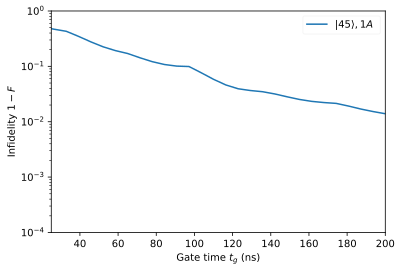

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(np.array(drive_param_14_1A_combine)[:,1], Infidelity_14_1A_combine, '.-', label=r'$|14\rangle, 1A$ ')
# plt.plot(np.array(drive_param_14_2A_combine)[:,2], Infidelity_14_2A_combine, '.-', label=r'$|14\rangle, 2A$')
plt.plot(np.array(drive_param_45_1A)[:,1], Infidelity_45_1A, '-', label=r'$|45\rangle, 1A$ ')
# plt.plot(np.array(drive_param_45_2A)[:,2], Infidelity_45_2A, '.-', label=r'$|45\rangle, 2A$ ')
# plt.plot(np.array(drive_param_45_2A_tg20_better)[:,2], Infidelity_45_2A_tg20_better, '.-', label=r'$|45\rangle, 2A, 20$ ')
# plt.plot(np.array(drive_param_45_2A_tg20)[:,2], Infidelity_45_2A_tg20, '.-', label=r'$|45\rangle, 2A, 20$ ')
# plt.plot(np.array(drive_param_45_2A_tg26_better)[:,2], Infidelity_45_2A_tg26_better, '.-', label=r'$|45\rangle, 2A, 26$ ')
# plt.plot(np.array(drive_param_45_2A_tg26)[:,2], Infidelity_45_2A_tg26, '.-', label=r'$|45\rangle, 2A, 26$ ')
# plt.plot(merged_45_2A_better[:,2], Infidelity_45_2A_better, 'x', label=r'$|45\rangle, 2A$, better ')
# plt.plot(merged_45_2A[:,2], Infidelity_45_2A, 'x', label=r'$|45\rangle, 2A,$ ')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
# plt.grid()
plt.xlim(25,200)
plt.ylim(0.0001,1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent
# plt.savefig('cnot_fidelity_2A0_and_1A0.png',dpi=300,bbox_inches='tight')